# Disease Identification POC (Notebook-First)

## Objective
Train and evaluate an initial **multi-label disease identification** model for:

- `AURI`
- `PN`
- `TB`
- `COVID`

This POC fine-tunes a local ELECTRA transformer checkpoint on the curated training data in `data/training_data/training_1.csv`. Each run starts from the latest saved training weights in `artifacts/poc_transformers/electra_local_finetuned` when available, and falls back to `models/model.safetensors` for the first run.


In [15]:
# Environment setup
import ast
import json
import random
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Notebook Python executable:', sys.executable)

try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency 'torch' in this notebook kernel. "
        f"Install it with `{sys.executable} -m pip install torch`."
    ) from exc

try:
    accelerate_version = version('accelerate')
except PackageNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency 'accelerate>=1.1.0' in this notebook kernel. "
        f"Install it with `{sys.executable} -m pip install -U 'accelerate>=1.1.0'`, "
        "then restart the notebook kernel."
    ) from exc

if tuple(int(part) for part in accelerate_version.split('.')[:2]) < (1, 1):
    raise ImportError(
        f"Installed accelerate=={accelerate_version}, but Trainer requires accelerate>=1.1.0. "
        f"Upgrade it with `{sys.executable} -m pip install -U 'accelerate>=1.1.0'`, "
        "then restart the notebook kernel."
    )

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    hamming_loss,
    precision_recall_fscore_support,
)
from torch.utils.data import Dataset

try:
    from safetensors.torch import load_file as load_safetensors_file
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency 'safetensors' in this notebook kernel. "
        f"Install it with `{sys.executable} -m pip install safetensors`."
    ) from exc

try:
    from transformers import (
        AutoConfig,
        AutoModelForSequenceClassification,
        AutoTokenizer,
        Trainer,
        TrainingArguments,
        set_seed,
    )
    from transformers.utils import is_accelerate_available
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency 'transformers' in this notebook kernel. "
        f"Install it with `{sys.executable} -m pip install transformers`."
    ) from exc

if not is_accelerate_available('1.1.0'):
    raise RuntimeError(
        "Transformers still cannot see accelerate>=1.1.0. "
        "If you installed accelerate during this notebook session, restart the kernel and run from the first cell. "
        f"Current kernel executable: {sys.executable}"
    )

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)


def select_runtime_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


DEVICE = select_runtime_device()
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    DEVICE_DESCRIPTION = f"cuda ({torch.cuda.get_device_name(0)})"
elif DEVICE.type == 'mps':
    DEVICE_DESCRIPTION = 'mps'
else:
    DEVICE_DESCRIPTION = 'cpu'

print('Torch runtime device:', DEVICE_DESCRIPTION)

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')


Notebook Python executable: /Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/.venv/bin/python


In [16]:
# Config
CWD = Path.cwd()
ROOT_DIR = next((p for p in [CWD, *CWD.parents] if (p / '.git').exists()), CWD)

DATA_PATH = (ROOT_DIR / 'data' / 'training_data' / 'training_1.csv').resolve()
# DATA_PATH = [(ROOT_DIR / 'data' / 'training_data' / name).resolve() for name in ('training_1.csv', 'training_2.csv')]
DATA_PATHS = [DATA_PATH] if isinstance(DATA_PATH, Path) else [Path(path).resolve() for path in DATA_PATH]
TEXT_COL = 'post'
LABEL_COL = 'annotate'
BOOTSTRAP_WEIGHTS_PATH = (ROOT_DIR / 'models' / 'model.safetensors').resolve()
BASE_MODEL_NAME = 'google/electra-small-discriminator'
MODEL_KEY = 'electra_local_finetuned'

TEST_SIZE = 0.10
VAL_SIZE = 0.10  # fraction of full dataset
LABELS = ['AURI', 'PN', 'TB', 'COVID']
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

ARTIFACT_DIR = ROOT_DIR / 'artifacts' / 'poc_transformers' / MODEL_KEY
REPORT_DIR = ROOT_DIR / 'reports' / 'poc_transformers'


def find_latest_trained_weights():
    trained_weight_candidates = [
        ARTIFACT_DIR / 'best_model' / 'model.safetensors',
        ARTIFACT_DIR / 'model' / 'model.safetensors',
        *sorted((ARTIFACT_DIR / 'trainer_output').glob('checkpoint-*/model.safetensors')),
    ]
    existing_candidates = [p.resolve() for p in trained_weight_candidates if p.exists()]
    if not existing_candidates:
        return None
    return max(existing_candidates, key=lambda p: p.stat().st_mtime)


def resolve_initial_weights_path():
    latest_trained_weights = find_latest_trained_weights()
    if latest_trained_weights is not None:
        return latest_trained_weights, 'trained_artifact'
    if BOOTSTRAP_WEIGHTS_PATH.exists():
        return BOOTSTRAP_WEIGHTS_PATH, 'bootstrap_checkpoint'

    searched_paths = [
        ARTIFACT_DIR / 'best_model' / 'model.safetensors',
        ARTIFACT_DIR / 'model' / 'model.safetensors',
        ARTIFACT_DIR / 'trainer_output' / 'checkpoint-*' / 'model.safetensors',
        BOOTSTRAP_WEIGHTS_PATH,
    ]
    raise FileNotFoundError(
        'Could not locate transformer weights. Checked: '
        + ', '.join(str(p) for p in searched_paths)
    )


LOCAL_WEIGHTS_PATH, LOCAL_WEIGHTS_SOURCE = resolve_initial_weights_path()
# LOCAL_WEIGHTS_PATH, LOCAL_WEIGHTS_SOURCE = BOOTSTRAP_WEIGHTS_PATH, 'bootstrap_checkpoint'

MAX_LENGTH = 128
BATCH_SIZE = 4
NUM_EPOCHS = 15
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

missing_data_paths = [path for path in DATA_PATHS if not path.exists()]
if missing_data_paths:
    raise FileNotFoundError(f'Could not locate training data: {missing_data_paths}')

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print()
print({
    'cwd': str(CWD),
    'root_dir': str(ROOT_DIR),
    'DATA_PATH': [str(path) for path in DATA_PATHS] if len(DATA_PATHS) > 1 else str(DATA_PATHS[0]),
    'TEXT_COL': TEXT_COL,
    'LABEL_COL': LABEL_COL,
    'BOOTSTRAP_WEIGHTS_PATH': str(BOOTSTRAP_WEIGHTS_PATH),
    'LOCAL_WEIGHTS_PATH': str(LOCAL_WEIGHTS_PATH),
    'LOCAL_WEIGHTS_SOURCE': LOCAL_WEIGHTS_SOURCE,
    'BASE_MODEL_NAME': BASE_MODEL_NAME,
    'MODEL_KEY': MODEL_KEY,
    'TEST_SIZE': TEST_SIZE,
    'VAL_SIZE': VAL_SIZE,
    'LABELS': LABELS,
    'DEVICE': str(DEVICE),
    'DEVICE_DESCRIPTION': DEVICE_DESCRIPTION,
    'ARTIFACT_DIR': str(ARTIFACT_DIR),
    'REPORT_DIR': str(REPORT_DIR),
})



{'cwd': '/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/notebooks', 'root_dir': '/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus', 'DATA_PATH': '/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/data/training_data/training_1.csv', 'TEXT_COL': 'post', 'LABEL_COL': 'annotate', 'LOCAL_WEIGHTS_PATH': '/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/models/model.safetensors', 'BASE_MODEL_NAME': 'google/electra-small-discriminator', 'MODEL_KEY': 'electra_local_finetuned', 'TEST_SIZE': 0.1, 'VAL_SIZE': 0.1, 'LABELS': ['AURI', 'PN', 'TB', 'COVID'], 'ARTIFACT_DIR': '/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/artifacts/poc_transformers/electra_local_finetuned', 'REPORT_DIR': '/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/reports/poc_transformers'}


In [17]:
# Data loading + strict validation for preprocessed inputs (no text cleaning)
def parse_label_vector(value, expected_len=4):
    if not isinstance(value, str):
        raise ValueError(f'{LABEL_COL} must be string; got {type(value)}')

    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError) as exc:
        raise ValueError(f'Invalid label literal: {value}') from exc

    if not isinstance(parsed, (list, tuple)):
        raise ValueError(f'label value must parse to list/tuple: {value}')

    if len(parsed) != expected_len:
        raise ValueError(f'label vector length must be {expected_len}: {value}')

    if any(item not in (0, 1) for item in parsed):
        raise ValueError(f'label values must be binary 0/1: {value}')

    return [int(item) for item in parsed]


def validate_preprocessed_dataset(df):
    required_cols = {TEXT_COL, LABEL_COL}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f'Missing required columns: {sorted(missing)}')

    valid_text = df[TEXT_COL].map(lambda value: isinstance(value, str))
    if not valid_text.all():
        bad_count = int((~valid_text).sum())
        raise ValueError(f'{bad_count} rows have non-string text')

    label_vectors = df[LABEL_COL].map(lambda value: parse_label_vector(value, expected_len=len(LABELS)))
    label_df = pd.DataFrame(label_vectors.tolist(), columns=LABELS, index=df.index)

    return pd.concat(
        [
            df[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: 'text', LABEL_COL: 'annotate'}),
            label_df,
        ],
        axis=1,
    ).reset_index(drop=True)

def read_training_csv(path):
    df = pd.read_csv(path, keep_default_na=False)
    text_col = next((col for col in [TEXT_COL, 'cleaned_text'] if col in df.columns), None)
    label_col = next((col for col in [LABEL_COL, 'disease'] if col in df.columns), None)
    if text_col is None or label_col is None:
        raise ValueError(
            f'{path} must include text and label columns. '
            f'Accepted text columns: {[TEXT_COL, "cleaned_text"]}; '
            f'accepted label columns: {[LABEL_COL, "disease"]}'
        )
    return df.rename(columns={text_col: TEXT_COL, label_col: LABEL_COL})[[TEXT_COL, LABEL_COL]]


raw_df = pd.concat(
    (read_training_csv(path) for path in DATA_PATHS),
    ignore_index=True,
)
clean_df = validate_preprocessed_dataset(raw_df)

print('Raw rows:', len(raw_df))
print('Preprocessed rows:', len(clean_df))
print('Columns:', clean_df.columns.tolist())


Row count: 6290

Label counts:
AURI     1272
PN        859
TB        953
COVID    1285
dtype: int64

Label prevalence:
COVID    20.43%
AURI     20.22%
TB       15.15%
PN       13.66%
dtype: str

All-zero label rows: 4661


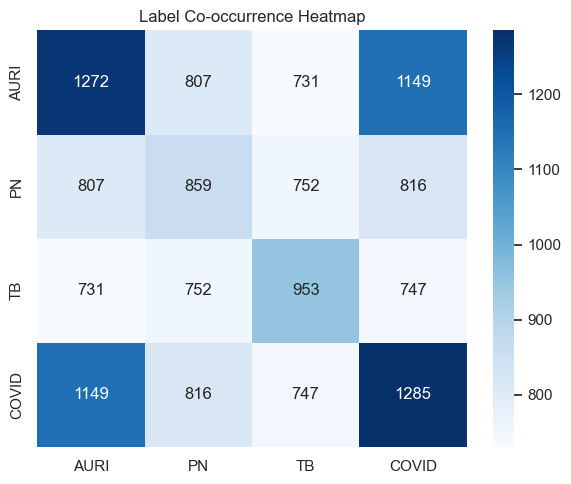

In [18]:
# Quick EDA
print('Row count:', len(clean_df))

label_counts = clean_df[LABELS].sum().astype(int)
label_prevalence = (label_counts / len(clean_df)).sort_values(ascending=False)

print('\nLabel counts:')
print(label_counts)
print('\nLabel prevalence:')
print((label_prevalence * 100).round(2).astype(str) + '%')

all_zero_count = int((clean_df[LABELS].sum(axis=1) == 0).sum())
print('\nAll-zero label rows:', all_zero_count)

cooccurrence = clean_df[LABELS].T.dot(clean_df[LABELS])
plt.figure(figsize=(6, 5))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues')
plt.title('Label Co-occurrence Heatmap')
plt.tight_layout()
plt.show()


In [19]:
# Iterative multi-label stratified split (custom, dependency-free)
def iterative_multilabel_split_indices(y, test_size=0.1, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y, dtype=int)

    n_samples, n_labels = y.shape
    n_test = int(round(n_samples * test_size))
    n_test = max(1, min(n_samples - 1, n_test))

    all_idx = np.arange(n_samples)
    unassigned = set(all_idx.tolist())
    test_idx = []

    target_test_label_counts = y.sum(axis=0) * test_size
    current_test_label_counts = np.zeros(n_labels, dtype=float)

    sample_label_counts = y.sum(axis=1)

    while len(test_idx) < n_test and unassigned:
        deficits = target_test_label_counts - current_test_label_counts
        deficits = np.where(deficits > 0, deficits, 0)

        if deficits.sum() == 0:
            remaining = np.array(list(unassigned))
            rng.shuffle(remaining)
            take = remaining[: (n_test - len(test_idx))]
            test_idx.extend(take.tolist())
            break

        label_order = np.argsort(-deficits)
        chosen = None

        for label in label_order:
            candidates = [i for i in unassigned if y[i, label] == 1]
            if not candidates:
                continue

            min_card = min(sample_label_counts[candidates])
            filtered = [i for i in candidates if sample_label_counts[i] == min_card]
            chosen = int(rng.choice(filtered))
            break

        if chosen is None:
            chosen = int(rng.choice(np.array(list(unassigned))))

        test_idx.append(chosen)
        unassigned.remove(chosen)
        current_test_label_counts += y[chosen]

    test_idx = np.array(sorted(set(test_idx)))
    train_idx = np.array(sorted(list(set(all_idx) - set(test_idx))))
    return train_idx, test_idx


def build_splits(df, labels, test_size=0.1, val_size=0.1, random_state=42):
    y_all = df[labels].values

    trainval_idx, test_idx = iterative_multilabel_split_indices(
        y_all, test_size=test_size, random_state=random_state
    )

    trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)

    y_trainval = trainval_df[labels].values
    val_relative = val_size / (1.0 - test_size)

    train_idx_local, val_idx_local = iterative_multilabel_split_indices(
        y_trainval, test_size=val_relative, random_state=random_state
    )

    train_df = trainval_df.iloc[train_idx_local].reset_index(drop=True)
    val_df = trainval_df.iloc[val_idx_local].reset_index(drop=True)

    return train_df, val_df, test_df

train_df, val_df, test_df = build_splits(
    clean_df,
    labels=LABELS,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=SEED,
)

print('Split sizes:')
print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))
print('total check:', len(train_df) + len(val_df) + len(test_df), '==', len(clean_df))

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    prevalence = (part[LABELS].mean() * 100).round(2)
    print(f"\n{name} label prevalence (%)")
    print(prevalence.to_dict())



Split sizes:
train: 5032 val: 629 test: 629
total check: 6290 == 6290

train label prevalence (%)
{'AURI': 17.69, 'PN': 11.92, 'TB': 13.29, 'COVID': 17.75}

val label prevalence (%)
{'AURI': 31.64, 'PN': 21.3, 'TB': 23.21, 'COVID': 32.59}

test label prevalence (%)
{'AURI': 29.09, 'PN': 19.87, 'TB': 21.94, 'COVID': 29.73}


In [20]:
# Transformer training setup (local ELECTRA checkpoint)
import gc

y_train = train_df[LABELS].values.astype(np.float32)
y_val = val_df[LABELS].values.astype(np.float32)
y_test = test_df[LABELS].values.astype(np.float32)


class MultiLabelTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoded = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt',
        )
        item = {k: v.squeeze(0) for k, v in encoded.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item


def sigmoid_logits(logits):
    return 1 / (1 + np.exp(-logits))


def compute_eval_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid_logits(logits)
    preds = (probs >= 0.5).astype(int)
    labels = labels.astype(int)

    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        labels, preds, average='micro', zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )

    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'micro_precision': float(micro_p),
        'micro_recall': float(micro_r),
        'micro_f1': float(micro_f1),
        'macro_precision': float(macro_p),
        'macro_recall': float(macro_r),
        'macro_f1': float(macro_f1),
        'hamming_loss': float(hamming_loss(labels, preds)),
    }


def clear_device_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        torch.mps.empty_cache()


def build_local_electra_model():
    config = AutoConfig.from_pretrained(
        BASE_MODEL_NAME,
        num_labels=len(LABELS),
        problem_type='multi_label_classification',
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )
    model = AutoModelForSequenceClassification.from_config(config)
    state_dict = load_safetensors_file(str(LOCAL_WEIGHTS_PATH), device='cpu')

    try:
        model.load_state_dict(state_dict, strict=True)
    except RuntimeError as exc:
        raise RuntimeError(
            f'{LOCAL_WEIGHTS_PATH} does not match the inferred ELECTRA architecture '
            f'for {BASE_MODEL_NAME} with {len(LABELS)} labels.'
        ) from exc

    return model


def train_local_electra():
    print(
        f'\n=== Fine-tuning {MODEL_KEY}: {BASE_MODEL_NAME} '
        f'from {LOCAL_WEIGHTS_PATH} ({LOCAL_WEIGHTS_SOURCE}) ==='
    )
    clear_device_cache()

    model_dir = ARTIFACT_DIR / 'model'
    trainer_output_dir = ARTIFACT_DIR / 'trainer_output'
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, use_fast=True)
    model = build_local_electra_model().to(DEVICE)

    train_ds = MultiLabelTextDataset(train_df['text'], y_train, tokenizer, max_length=MAX_LENGTH)
    val_ds = MultiLabelTextDataset(val_df['text'], y_val, tokenizer, max_length=MAX_LENGTH)
    test_ds = MultiLabelTextDataset(test_df['text'], y_test, tokenizer, max_length=MAX_LENGTH)

    training_args = TrainingArguments(
        output_dir=str(trainer_output_dir),
        eval_strategy='epoch',
        save_strategy='epoch',
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model='eval_micro_f1',
        greater_is_better=True,
        logging_steps=25,
        save_total_limit=1,
        gradient_checkpointing=True,
        report_to='none',
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_eval_metrics,
    )
    print('Trainer selected device:', trainer.args.device)

    train_result = trainer.train()
    trainer_log_history = [dict(row) for row in trainer.state.log_history]

    val_prediction = trainer.predict(val_ds, metric_key_prefix='val')
    test_prediction = trainer.predict(test_ds, metric_key_prefix='test')
    val_logits = val_prediction.predictions
    test_logits = test_prediction.predictions

    trainer.model.save_pretrained(model_dir)
    tokenizer.save_pretrained(model_dir)

    run_result = {
        'model_key': MODEL_KEY,
        'base_model_name': BASE_MODEL_NAME,
        'local_weights_path': str(LOCAL_WEIGHTS_PATH),
        'local_weights_source': LOCAL_WEIGHTS_SOURCE,
        'model_dir': str(model_dir),
        'val_proba': sigmoid_logits(val_logits),
        'test_proba': sigmoid_logits(test_logits),
        'train_metrics': train_result.metrics,
        'trainer_log_history': trainer_log_history,
        'val_trainer_metrics': val_prediction.metrics,
        'test_trainer_metrics': test_prediction.metrics,
    }

    del trainer, model, tokenizer, train_ds, val_ds, test_ds, train_result, val_prediction, test_prediction, val_logits, test_logits
    clear_device_cache()

    return run_result


In [21]:
# Train local ELECTRA model
run = train_local_electra()
print('Completed transformer training for:', run['model_key'])



=== Fine-tuning electra_local_finetuned: google/electra-small-discriminator from /Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/models/model.safetensors ===


/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.143565,0.307429,0.748808,0.759162,0.847953,0.801105,0.750355,0.842296,0.793172,0.114467,2.512000,250.394000,62.897000
2,0.053323,0.477369,0.734499,0.742857,0.836257,0.786795,0.734735,0.831330,0.778984,0.123211,2.492100,252.401000,63.401000
3,0.024002,0.556170,0.734499,0.762431,0.807018,0.784091,0.752083,0.798135,0.774234,0.120827,2.474700,254.175000,63.847000
4,0.181782,0.592382,0.732909,0.759134,0.820175,0.788475,0.751034,0.815108,0.780809,0.119634,2.377400,264.574000,66.459000
5,0.015402,0.702113,0.729730,0.752055,0.802632,0.776521,0.743185,0.795041,0.767052,0.125596,2.490800,252.526000,63.433000
6,0.098160,0.789237,0.729730,0.748982,0.807018,0.776918,0.740609,0.801051,0.768415,0.125994,2.432800,258.546000,64.945000
7,0.029727,0.822989,0.729730,0.769341,0.785088,0.777135,0.757769,0.772358,0.764858,0.122417,2.349100,267.763000,67.260000
8,0.000574,0.863082,0.717011,0.753501,0.786550,0.769671,0.743320,0.777037,0.759429,0.127981,2.487300,252.883000,63.522000
9,0.055573,0.885284,0.728140,0.763791,0.789474,0.776420,0.752739,0.778714,0.765299,0.123609,2.407500,261.263000,65.627000
10,0.004234,0.895642,0.731320,0.772857,0.790936,0.781792,0.760860,0.778678,0.769259,0.120032,2.306000,272.767000,68.517000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.80it/s]
/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.31it/s]
/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.80it/s]
/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader

/Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.02it/s]


Completed transformer training for: electra_local_finetuned


In [22]:
# Validation threshold tuning (per label)
def tune_thresholds(y_true, y_proba, labels, start=0.10, stop=0.90, step=0.01):
    thresholds = {}
    details = {}
    grid = np.arange(start, stop + 1e-9, step)

    for i, label in enumerate(labels):
        best_t = 0.5
        best_f1 = -1.0

        for t in grid:
            pred = (y_proba[:, i] >= t).astype(int)
            p, r, f1, _ = precision_recall_fscore_support(
                y_true[:, i], pred, average='binary', zero_division=0
            )
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(np.round(t, 4))
                best_p, best_r = p, r

        thresholds[label] = best_t
        details[label] = {
            'precision': float(best_p),
            'recall': float(best_r),
            'f1': float(best_f1),
        }

    return thresholds, details


def apply_thresholds(y_proba, thresholds, labels):
    out = np.zeros_like(y_proba, dtype=int)
    for i, label in enumerate(labels):
        out[:, i] = (y_proba[:, i] >= thresholds[label]).astype(int)
    return out


def compute_metrics(y_true, y_pred, labels):
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='micro', zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    ham = hamming_loss(y_true, y_pred)
    accuracy = float(accuracy_score(y_true, y_pred))

    per_label = {}
    for i, label in enumerate(labels):
        p, r, f1, _ = precision_recall_fscore_support(
            y_true[:, i], y_pred[:, i], average='binary', zero_division=0
        )
        per_label[label] = {
            'precision': float(p),
            'recall': float(r),
            'f1': float(f1),
        }

    return {
        'accuracy': accuracy,
        'exact_match_ratio': accuracy,
        'micro_precision': float(micro_p),
        'micro_recall': float(micro_r),
        'micro_f1': float(micro_f1),
        'macro_precision': float(macro_p),
        'macro_recall': float(macro_r),
        'macro_f1': float(macro_f1),
        'hamming_loss': float(ham),
        'per_label': per_label,
    }


def extract_loss_history(log_history):
    rows = []
    for item in log_history:
        step = item.get('step')
        epoch = item.get('epoch')
        if 'loss' in item:
            rows.append({
                'split': 'train',
                'step': int(step) if step is not None else None,
                'epoch': float(epoch) if epoch is not None else None,
                'loss': float(item['loss']),
            })
        if 'eval_loss' in item:
            rows.append({
                'split': 'validation',
                'step': int(step) if step is not None else None,
                'epoch': float(epoch) if epoch is not None else None,
                'loss': float(item['eval_loss']),
            })

    return pd.DataFrame(rows, columns=['split', 'step', 'epoch', 'loss'])


def build_validation_confusion_matrices(y_true, y_pred, labels):
    rows = []
    matrices = {}
    for i, label in enumerate(labels):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
        tn, fp, fn, tp = [int(v) for v in cm.ravel()]
        rows.append({
            'model': MODEL_KEY,
            'split': 'val',
            'label': label,
            'tn': tn,
            'fp': fp,
            'fn': fn,
            'tp': tp,
        })
        matrices[label] = {
            'tn': tn,
            'fp': fp,
            'fn': fn,
            'tp': tp,
            'matrix': [[tn, fp], [fn, tp]],
        }

    return pd.DataFrame(rows), matrices


def plot_loss_history(loss_history_df, output_path):
    if loss_history_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(9, 5))
    for split, label in [('train', 'Training loss'), ('validation', 'Validation loss')]:
        split_df = loss_history_df[loss_history_df['split'] == split]
        if split_df.empty:
            continue
        ax.plot(split_df['step'], split_df['loss'], marker='o', linewidth=1.8, label=label)

    ax.set_title('Training and validation loss')
    ax.set_xlabel('Training step')
    ax.set_ylabel('Loss')
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.close(fig)
    return output_path


def plot_validation_confusion_matrices(validation_confusion_df, output_path):
    if validation_confusion_df.empty:
        return None

    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    for ax, row in zip(axes.flat, validation_confusion_df.to_dict('records')):
        matrix = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]])
        sns.heatmap(
            matrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'],
            ax=ax,
        )
        ax.set_title(row['label'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    fig.suptitle('Validation confusion matrices', y=1.02)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close(fig)
    return output_path


thresholds, val_label_metrics = tune_thresholds(y_val.astype(int), run['val_proba'], LABELS)
y_val_pred = apply_thresholds(run['val_proba'], thresholds, LABELS)
val_metrics = compute_metrics(y_val.astype(int), y_val_pred, LABELS)
val_metrics = {
    'loss': run.get('val_trainer_metrics', {}).get('val_loss'),
    **val_metrics,
}
loss_history_df = extract_loss_history(run.get('trainer_log_history', []))
validation_confusion_df, validation_confusion_matrices = build_validation_confusion_matrices(
    y_val.astype(int), y_val_pred, LABELS
)

print('Validation metrics:')
print(json.dumps(val_metrics, indent=2))
print('Validation thresholds:')
print(json.dumps(thresholds, indent=2))
print('Validation confusion matrices:')
display(validation_confusion_df)


Validation metrics:
{
  "loss": 0.30742913484573364,
  "accuracy": 0.7567567567567568,
  "exact_match_ratio": 0.7567567567567568,
  "micro_precision": 0.7373271889400922,
  "micro_recall": 0.935672514619883,
  "micro_f1": 0.8247422680412371,
  "macro_precision": 0.7317972452023457,
  "macro_recall": 0.9355368563048022,
  "macro_f1": 0.8188150250793705,
  "hamming_loss": 0.10810810810810811,
  "per_label": {
    "AURI": {
      "precision": 0.8181818181818182,
      "recall": 0.949748743718593,
      "f1": 0.8790697674418605
    },
    "PN": {
      "precision": 0.6684210526315789,
      "recall": 0.9477611940298507,
      "f1": 0.7839506172839507
    },
    "TB": {
      "precision": 0.6320754716981132,
      "recall": 0.9178082191780822,
      "f1": 0.7486033519553073
    },
    "COVID": {
      "precision": 0.8085106382978723,
      "recall": 0.926829268292683,
      "f1": 0.8636363636363636
    }
  }
}
Validation thresholds:
{
  "AURI": 0.1,
  "PN": 0.12,
  "TB": 0.1,
  "COVID": 0.1

In [23]:
# Final test evaluation
test_proba = run['test_proba']
y_test_pred = apply_thresholds(test_proba, thresholds, LABELS)
metrics = compute_metrics(y_test.astype(int), y_test_pred, LABELS)
metrics = {
    'loss': run.get('test_trainer_metrics', {}).get('test_loss'),
    **metrics,
}

model = AutoModelForSequenceClassification.from_pretrained(run['model_dir']).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(run['model_dir'], use_fast=True)

print('Test metrics:')
print(json.dumps(metrics, indent=2))

success = metrics['micro_f1'] >= 0.75
print('\nSUCCESS GATE (Micro-F1 >= 0.75):', 'PASS' if success else 'FAIL')


Loading weights: 100%|██████████| 203/203 [00:24<00:00,  8.12it/s]

Test metrics:
{
  "loss": 0.6216105818748474,
  "accuracy": 0.505564387917329,
  "exact_match_ratio": 0.505564387917329,
  "micro_precision": 0.5507246376811594,
  "micro_recall": 0.8404423380726699,
  "micro_f1": 0.66541588492808,
  "macro_precision": 0.5461288501294331,
  "macro_recall": 0.8351902671001661,
  "macro_f1": 0.6600016059900723,
  "hamming_loss": 0.21263910969793323,
  "per_label": {
    "AURI": {
      "precision": 0.6014760147601476,
      "recall": 0.8907103825136612,
      "f1": 0.7180616740088106
    },
    "PN": {
      "precision": 0.5133689839572193,
      "recall": 0.768,
      "f1": 0.6153846153846154
    },
    "TB": {
      "precision": 0.5064935064935064,
      "recall": 0.8478260869565217,
      "f1": 0.6341463414634146
    },
    "COVID": {
      "precision": 0.5631768953068592,
      "recall": 0.8342245989304813,
      "f1": 0.6724137931034483
    }
  }
}

SUCCESS GATE (Micro-F1 >= 0.75): FAIL


In [24]:
# Save artifacts + reports
best_model_dir = ARTIFACT_DIR / 'best_model'
best_model_dir.mkdir(parents=True, exist_ok=True)

model.save_pretrained(best_model_dir)
tokenizer.save_pretrained(best_model_dir)

with open(ARTIFACT_DIR / 'thresholds.json', 'w', encoding='utf-8') as f:
    json.dump(thresholds, f, indent=2)

with open(ARTIFACT_DIR / 'label_order.json', 'w', encoding='utf-8') as f:
    json.dump(LABELS, f, indent=2)

best_model_info = {
    'model_key': MODEL_KEY,
    'base_model_name': BASE_MODEL_NAME,
    'local_weights_path': str(LOCAL_WEIGHTS_PATH),
    'local_weights_source': LOCAL_WEIGHTS_SOURCE,
    'model_dir': run['model_dir'],
}
with open(ARTIFACT_DIR / 'best_model_info.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_info, f, indent=2)

loss_history_path = REPORT_DIR / f'{MODEL_KEY}_training_validation_loss.csv'
loss_plot_path = REPORT_DIR / f'{MODEL_KEY}_training_validation_loss.png'
validation_confusion_path = REPORT_DIR / f'{MODEL_KEY}_validation_confusion_matrix.csv'
validation_confusion_plot_path = REPORT_DIR / f'{MODEL_KEY}_validation_confusion_matrices.png'
per_label_metrics_path = REPORT_DIR / f'{MODEL_KEY}_per_label_metrics.csv'

metrics_payload = {
    'label_order': LABELS,
    'selected_model': best_model_info,
    'thresholds': thresholds,
    'training': {
        'metrics': run.get('train_metrics', {}),
        'log_history': run.get('trainer_log_history', []),
    },
    'validation': {
        'threshold_f1': val_label_metrics,
        'metrics': val_metrics,
        'trainer_metrics': run.get('val_trainer_metrics', {}),
        'confusion_matrices': validation_confusion_matrices,
    },
    'metrics': metrics,
    'trainer_test_metrics': run.get('test_trainer_metrics', {}),
    'report_artifacts': {
        'loss_history_csv': str(loss_history_path),
        'loss_plot_png': str(loss_plot_path),
        'validation_confusion_matrix_csv': str(validation_confusion_path),
        'validation_confusion_matrices_png': str(validation_confusion_plot_path),
        'per_label_metrics_csv': str(per_label_metrics_path),
    },
    'success_micro_f1_ge_0_75': bool(metrics['micro_f1'] >= 0.75),
}

per_label_rows = []
for split_name, split_metrics in [('val', val_metrics), ('test', metrics)]:
    for label in LABELS:
        label_metrics = split_metrics['per_label'][label]
        per_label_rows.append({
            'model': MODEL_KEY,
            'split': split_name,
            'label': label,
            'precision': label_metrics['precision'],
            'recall': label_metrics['recall'],
            'f1': label_metrics['f1'],
        })

per_label_metrics_df = pd.DataFrame(
    per_label_rows,
    columns=['model', 'split', 'label', 'precision', 'recall', 'f1'],
)
per_label_metrics_df.to_csv(per_label_metrics_path, index=False)
loss_history_df.to_csv(loss_history_path, index=False)
validation_confusion_df.to_csv(validation_confusion_path, index=False)
plot_loss_history(loss_history_df, loss_plot_path)
plot_validation_confusion_matrices(validation_confusion_df, validation_confusion_plot_path)

with open(REPORT_DIR / 'poc_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2)

with open(REPORT_DIR / 'poc_transformer_model_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            MODEL_KEY: {
                'base_model_name': BASE_MODEL_NAME,
                'local_weights_path': str(LOCAL_WEIGHTS_PATH),
                'local_weights_source': LOCAL_WEIGHTS_SOURCE,
                'report_artifacts': metrics_payload['report_artifacts'],
                'validation': metrics_payload['validation'],
                'test': {
                    'thresholds': thresholds,
                    'metrics': metrics,
                    'trainer_metrics': run.get('test_trainer_metrics', {}),
                },
            }
        },
        f,
        indent=2,
    )

# Error samples
rows = []
for i in range(len(test_df)):
    if not np.array_equal(y_test[i].astype(int), y_test_pred[i]):
        probs = {label: float(test_proba[i, j]) for j, label in enumerate(LABELS)}
        true_labels = [label for j, label in enumerate(LABELS) if int(y_test[i, j]) == 1]
        pred_labels = [label for j, label in enumerate(LABELS) if y_test_pred[i, j] == 1]
        rows.append({
            'text': test_df.iloc[i]['text'],
            'true_labels': ','.join(true_labels) if true_labels else 'NONE',
            'pred_labels': ','.join(pred_labels) if pred_labels else 'NONE',
            'probabilities': json.dumps(probs),
        })

error_df = pd.DataFrame(rows)
error_df.to_csv(REPORT_DIR / 'poc_error_samples.csv', index=False)

print('Saved selected model artifacts to', best_model_dir)
print('Saved reports to', REPORT_DIR)
print('Saved per-disease metrics to', per_label_metrics_path)
print('Saved loss history to', loss_history_path)
print('Saved loss plot to', loss_plot_path)
print('Saved validation confusion matrix to', validation_confusion_path)
print('Saved validation confusion matrix plot to', validation_confusion_plot_path)
print('Error samples:', len(error_df))


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 22.07it/s]

Saved selected model artifacts to /Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/artifacts/poc_transformers/electra_local_finetuned/best_model
Saved reports to /Users/angelodelapaz/Documents/GitHub/HealthPH-Plus/reports/poc_transformers
Error samples: 311


In [25]:
# Inference demo function (contract: labels + probabilities + thresholds_used)
model.eval()


def predict_disease_labels(text):
    if not isinstance(text, str) or not text.strip():
        raise ValueError('text must be a non-empty string')

    encoded = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt',
    )

    device = next(model.parameters()).device
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        logits = model(**encoded).logits

    proba = torch.sigmoid(logits).cpu().numpy()[0]

    probabilities = {label: float(proba[i]) for i, label in enumerate(LABELS)}
    labels = [label for i, label in enumerate(LABELS) if proba[i] >= thresholds[label]]

    return {
        'labels': labels,
        'probabilities': probabilities,
        'thresholds_used': thresholds,
    }


examples = [
    'I have fever, dry cough, and sore throat for 2 days.',
    'ubong may dugo at hirap huminga ako nitong gabi',
    'feeling okay, no symptoms today',
]

for text in examples:
    print('\nINPUT:', text)
    print(json.dumps(predict_disease_labels(text), indent=2))



INPUT: I have fever, dry cough, and sore throat for 2 days.
{
  "labels": [
    "AURI",
    "PN",
    "TB",
    "COVID"
  ],
  "probabilities": {
    "AURI": 0.9996163845062256,
    "PN": 0.7166346311569214,
    "TB": 0.6130887866020203,
    "COVID": 0.9994966983795166
  },
  "thresholds_used": {
    "AURI": 0.1,
    "PN": 0.12,
    "TB": 0.1,
    "COVID": 0.1
  }
}

INPUT: ubong may dugo at hirap huminga ako nitong gabi
{
  "labels": [
    "AURI",
    "PN",
    "TB",
    "COVID"
  ],
  "probabilities": {
    "AURI": 0.9997127652168274,
    "PN": 0.9644370675086975,
    "TB": 0.9573304653167725,
    "COVID": 0.9995631575584412
  },
  "thresholds_used": {
    "AURI": 0.1,
    "PN": 0.12,
    "TB": 0.1,
    "COVID": 0.1
  }
}

INPUT: feeling okay, no symptoms today
{
  "labels": [
    "AURI",
    "PN",
    "TB",
    "COVID"
  ],
  "probabilities": {
    "AURI": 0.9959885478019714,
    "PN": 0.9828946590423584,
    "TB": 0.9872457981109619,
    "COVID": 0.9957849383354187
  },
  "thresho

In [26]:
# Test cases and scenario checks
# 1) Parser rejects malformed label strings
bad_inputs = ['notalist', '[1,0,1]', '[1,2,0,1]', '[1,0,0,0,1]']
for bad in bad_inputs:
    try:
        parse_label_vector(bad)
        raise AssertionError(f'Expected parse failure for: {bad}')
    except ValueError:
        pass

# 2) Training-data contract
assert all(path.exists() for path in DATA_PATHS)
assert TEXT_COL == 'post'
assert LABEL_COL == 'annotate'
assert len(raw_df) > 0
assert len(clean_df) == len(raw_df)
assert clean_df['text'].tolist() == raw_df[TEXT_COL].tolist()
assert set(['text', 'annotate', *LABELS]).issubset(clean_df.columns)
assert clean_df[LABELS].isin([0, 1]).all().all()
assert LOCAL_WEIGHTS_PATH.exists()

# 3) Split reproducibility check (same seed => same texts)
train_df_2, val_df_2, test_df_2 = build_splits(
    clean_df,
    labels=LABELS,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=SEED,
)
assert train_df['text'].tolist() == train_df_2['text'].tolist()
assert val_df['text'].tolist() == val_df_2['text'].tolist()
assert test_df['text'].tolist() == test_df_2['text'].tolist()

# 4) Local model and tokenizer smoke checks
smoke_model = build_local_electra_model().to(DEVICE)
smoke_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, use_fast=True)
smoke_encoded = smoke_tokenizer('ubo at lagnat with sore throat', return_tensors='pt')
smoke_encoded = {k: v.to(DEVICE) for k, v in smoke_encoded.items()}
with torch.no_grad():
    smoke_logits = smoke_model(**smoke_encoded).logits
assert tuple(smoke_logits.shape) == (1, len(LABELS))
del smoke_model, smoke_tokenizer, smoke_encoded, smoke_logits
clear_device_cache()

# 5) Threshold JSON contract
with open(ARTIFACT_DIR / 'thresholds.json', 'r', encoding='utf-8') as f:
    loaded_thresholds = json.load(f)
assert list(loaded_thresholds.keys()) == LABELS

# 6) Inference schema checks
res_none = predict_disease_labels('random harmless text without symptoms')
res_single = predict_disease_labels('fever and dry cough only')
res_multi = predict_disease_labels('ubo, lagnat, hirap huminga, chest pain')

for res in [res_none, res_single, res_multi]:
    assert set(res.keys()) == {'labels', 'probabilities', 'thresholds_used'}
    assert set(res['probabilities'].keys()) == set(LABELS)
    assert set(res['thresholds_used'].keys()) == set(LABELS)
    assert isinstance(res['labels'], list)

# 7) End-to-end rerun readiness checks (artifacts present)
required_paths = [
    ARTIFACT_DIR / 'best_model' / 'config.json',
    ARTIFACT_DIR / 'best_model' / 'tokenizer_config.json',
    ARTIFACT_DIR / 'label_order.json',
    ARTIFACT_DIR / 'best_model_info.json',
    ARTIFACT_DIR / 'thresholds.json',
    REPORT_DIR / 'poc_metrics.json',
    REPORT_DIR / f'{MODEL_KEY}_per_label_metrics.csv',
    REPORT_DIR / f'{MODEL_KEY}_training_validation_loss.csv',
    REPORT_DIR / f'{MODEL_KEY}_training_validation_loss.png',
    REPORT_DIR / f'{MODEL_KEY}_validation_confusion_matrix.csv',
    REPORT_DIR / f'{MODEL_KEY}_validation_confusion_matrices.png',
    REPORT_DIR / 'poc_error_samples.csv',
    REPORT_DIR / 'poc_transformer_model_comparison.json',
]
missing_paths = [str(p) for p in required_paths if not p.exists()]
assert not missing_paths, f'Missing outputs: {missing_paths}'

weight_candidates = [
    ARTIFACT_DIR / 'best_model' / 'model.safetensors',
    ARTIFACT_DIR / 'best_model' / 'pytorch_model.bin',
]
assert any(p.exists() for p in weight_candidates), 'Missing transformer model weights.'

print('All POC tests passed.')


All POC tests passed.
